# Human Airways Digital Twin
**Course:** Digital Twins Modeling and Applications  
**Prof.** Marco E. Biancolini — Università degli Studi di Roma Tor Vergata  


**Dataset:** DiTiDE / EuroHPC — RBF Morph / Ansys Twin Builder

---
**Contents:**
1. Imports & data loading
2. Geometry deformation — 100 patients
3. Regional displacement analysis
4. Pressure analysis (CFD)
5. POD analysis (SVD)


## 1. Imports & Data Loading

In [2]:
import numpy as np
import pandas as pd
import struct
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

def read_bin_vector(path):
    """Read geometry .bin -> (N, 3) float64 array (XYZ coordinates)."""
    with open(path, 'rb') as f:
        count = struct.unpack('<q', f.read(8))[0]
        return np.frombuffer(f.read(count * 8), dtype=np.float64).reshape(-1, 3)

def read_bin_scalar(path):
    """Read pressure .bin -> (N,) float64 array (one value per point)."""
    with open(path, 'rb') as f:
        count = struct.unpack('<q', f.read(8))[0]
        return np.frombuffer(f.read(count * 8), dtype=np.float64)

# Load base mesh
pts = read_bin_vector('/Users/tairakhayev/Downloads/human-airways-project-main/Points/points.bin')

with open('settings.json') as f:
    ns = json.load(f)['namedSelections']

snap_files = sorted(Path('snapshots').glob('snapshot*.bin'),
                    key=lambda p: int(p.stem.replace('snapshot', '')))
pres_files = sorted(Path('Pressure/snapshots_pressure').glob('snapshot*.bin'),
                    key=lambda p: int(p.stem.replace('snapshot', '')))

# Load pre-computed results
results = pd.read_csv('results.csv')
results['num'] = results['snapshot'].str.extract(r'(\d+)').astype(int)
results = results.sort_values('num').reset_index(drop=True)

pressure = pd.read_csv('pressure_results.csv')
pressure['num'] = pressure['snapshot'].str.extract(r'(\d+)').astype(int)
pressure = pressure.sort_values('num').reset_index(drop=True)

doe = pd.read_csv('doe.csv')

print(f'Base mesh     : {len(pts):,} points')
print(f'Snapshots     : {len(snap_files)} patients')
print(f'Regions       : {len(ns)} anatomical regions')
print(f'DOE parameters: {doe.shape[1]-1} parameters per patient')
print()
print(f'Bounding box X: {pts[:,0].min():.3f} -> {pts[:,0].max():.3f} m')
print(f'Bounding box Y: {pts[:,1].min():.3f} -> {pts[:,1].max():.3f} m')
print(f'Bounding box Z: {pts[:,2].min():.3f} -> {pts[:,2].max():.3f} m')
print()
print('Binary format: 8-byte int64 header + N x float64 values')
print('Geometry snapshots: 3 values per point (X, Y, Z) -> displacement = snapshot - baseline')
print('Pressure snapshots: 1 scalar per point (Pa)      -> static air pressure on walls')


FileNotFoundError: [Errno 2] No such file or directory: 'points.bin'

## 2. Geometry Deformation — 100 Patients

Each snapshot = one virtual patient with unique anatomy (26 DOE parameters).  
**Displacement** = distance between deformed mesh (snapshot) and baseline mesh (points.bin).


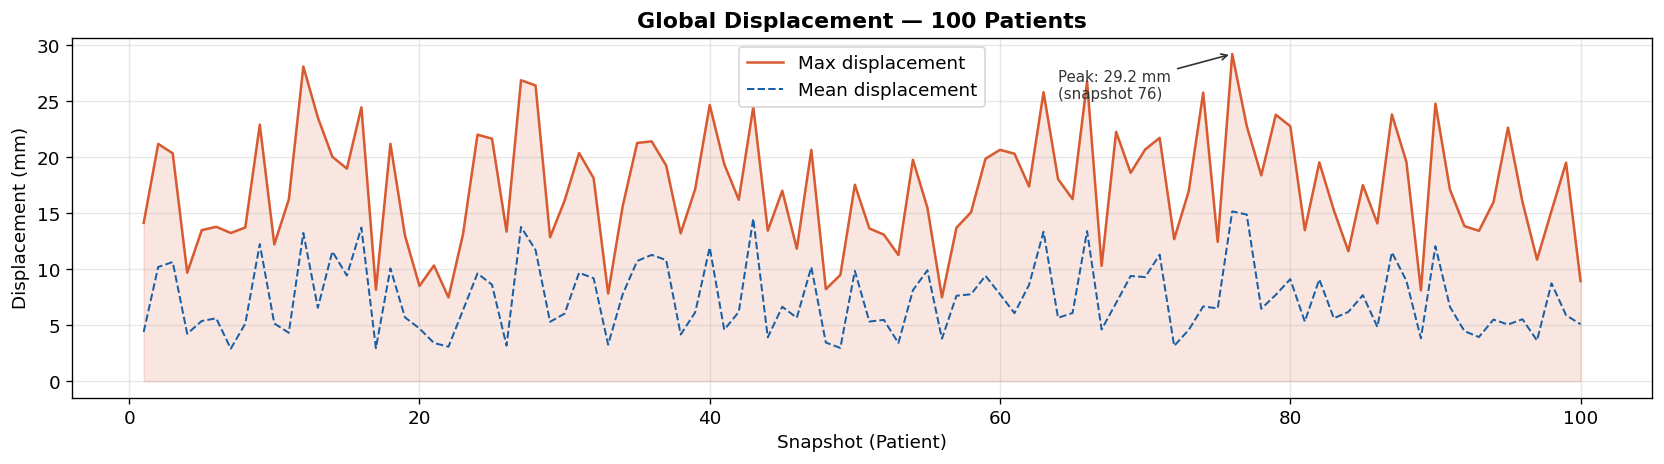

Max displacement: 29.2 mm  (snapshot 76))
Min displacement: 7.5 mm
Mean:             17.2 mm


In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.fill_between(results['num'], results['global_max'], alpha=0.15, color='#D85A30')
ax.plot(results['num'], results['global_max'],
        color='#D85A30', linewidth=1.5, label='Max displacement')
ax.plot(results['num'], results['global_mean'],
        color='#185FA5', linewidth=1.2, linestyle='--', label='Mean displacement')

peak_idx = results['global_max'].idxmax()
ax.annotate(
    f"Peak: {results.loc[peak_idx,'global_max']:.1f} mm\n(snapshot {results.loc[peak_idx,'num']})",
    xy=(results.loc[peak_idx,'num'], results.loc[peak_idx,'global_max']),
    xytext=(results.loc[peak_idx,'num']-12, results.loc[peak_idx,'global_max']-4),
    arrowprops=dict(arrowstyle='->', color='#333'),
    fontsize=9, color='#333')

ax.set_xlabel('Snapshot (Patient)')
ax.set_ylabel('Displacement (mm)')
ax.set_title('Global Displacement — 100 Patients', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Max displacement: {results['global_max'].max():.1f} mm  (snapshot {results.loc[peak_idx,'num']}))")
print(f"Min displacement: {results['global_max'].min():.1f} mm")
print(f"Mean:             {results['global_max'].mean():.1f} mm")


## 3. Regional Displacement Analysis

The airways are divided into **37 named anatomical regions** (defined in settings.json).  
Here we show displacement for the key regions.


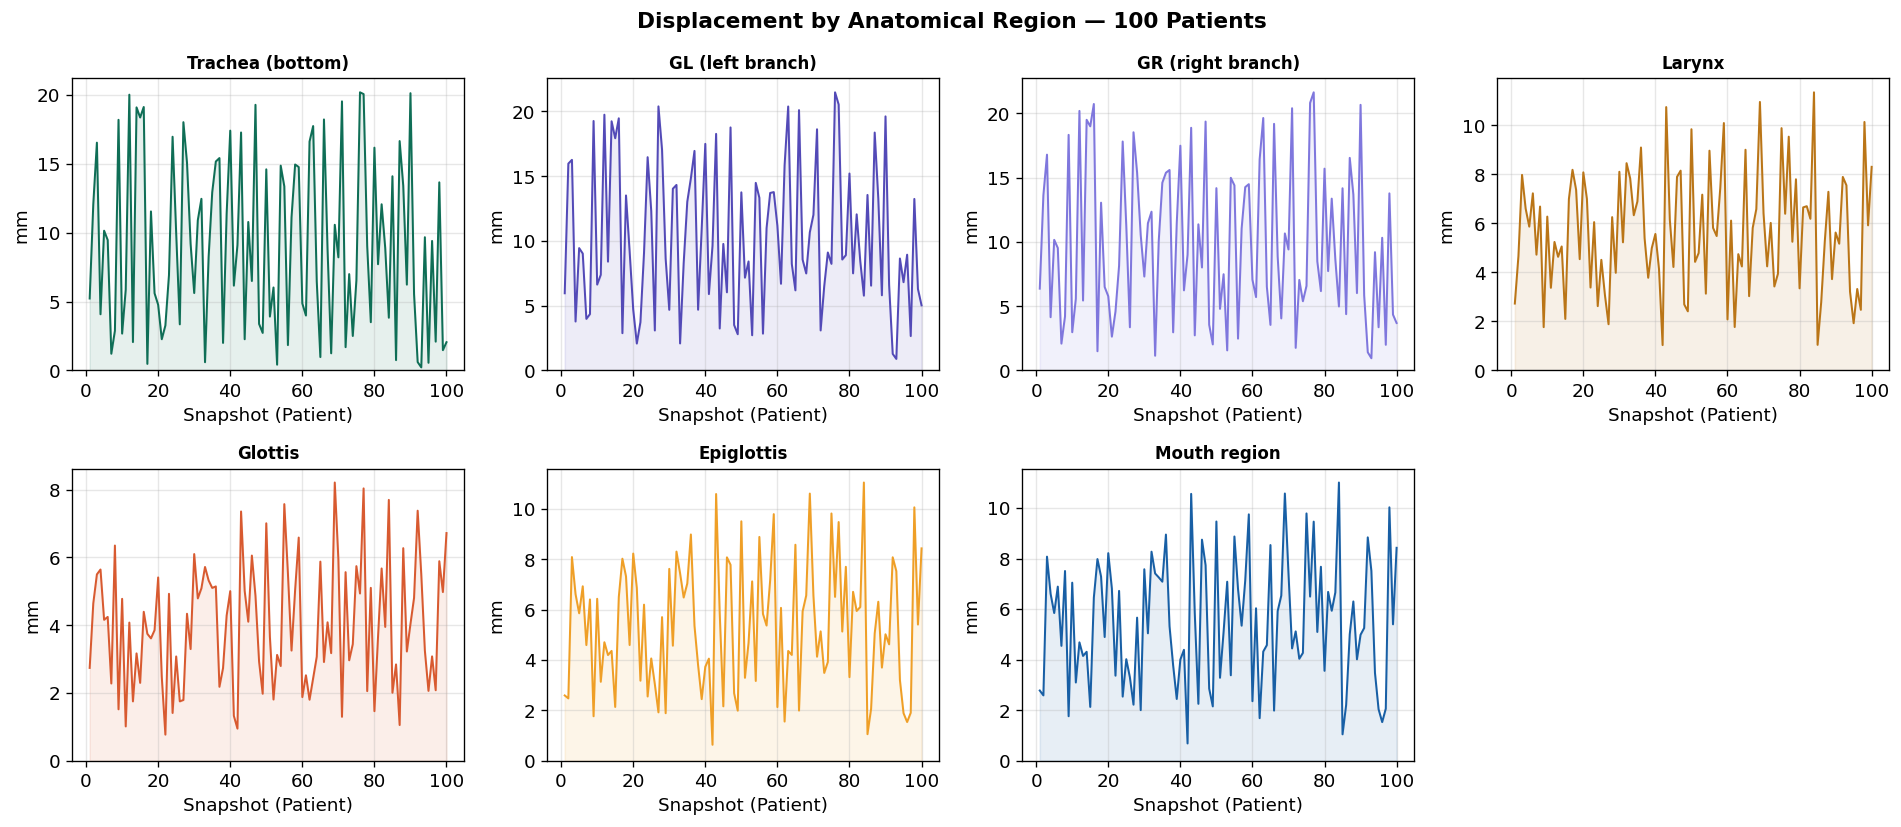

Mean max displacement per region (averaged over 100 patients):
  Trachea (bottom)    : 9.13 mm
  GL (left branch)    : 10.30 mm
  GR (right branch)   : 9.88 mm
  Larynx              : 5.68 mm
  Glottis             : 4.00 mm
  Epiglottis          : 5.37 mm
  Mouth region        : 5.50 mm


In [ ]:
regions = {
    'Trachea (bottom)': 'upper_trachea_bottom_max',
    'GL (left branch)': 'gl_max',
    'GR (right branch)':'gr_max',
    'Larynx':           'larynx_max',
    'Glottis':          'glotis_max',
    'Epiglottis':       'epiglotis_max',
    'Mouth region':     'mouth_region_max',
}

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
colors = ['#0F6E56','#534AB7','#7F77DD','#BA7517','#D85A30','#EF9F27','#185FA5']

for i, (label, col) in enumerate(regions.items()):
    ax = axes[i]
    ax.plot(results['num'], results[col], color=colors[i], linewidth=1.2)
    ax.fill_between(results['num'], results[col], alpha=0.1, color=colors[i])
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xlabel('Snapshot (Patient)')
    ax.set_ylabel('mm')
    ax.grid(alpha=0.3)
    ax.set_ylim(bottom=0)

axes[-1].set_visible(False)

plt.suptitle('Displacement by Anatomical Region — 100 Patients',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Summary table
print('Mean max displacement per region (averaged over 100 patients):')
for label, col in regions.items():
    print(f'  {label:<20s}: {results[col].mean():.2f} mm')


## 4. Pressure Analysis — CFD Results

Pressure snapshots contain **one scalar value per mesh point** (in Pascals).  
This is the static air pressure on the airway walls — result of the CFD simulation.


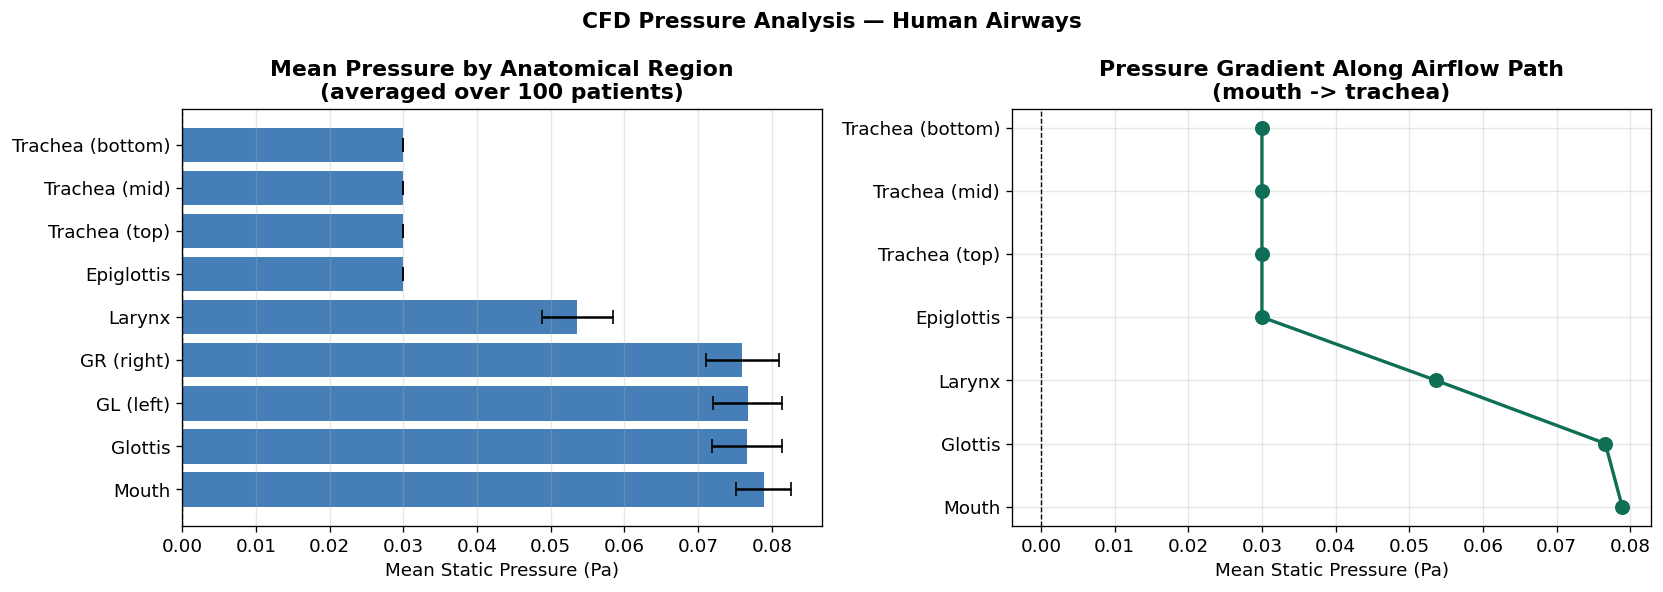

Pressure drop (glottis -> trachea): 0.0466 Pa
Physically correct: air flows from high pressure (mouth) to low pressure (trachea).


In [ ]:
pres_regions = {
    'Mouth':            'mouth_region_mean_Pa',
    'Glottis':          'glotis_mean_Pa',
    'GL (left)':        'gl_mean_Pa',
    'GR (right)':       'gr_mean_Pa',
    'Larynx':           'larynx_mean_Pa',
    'Epiglottis':       'epiglotis_mean_Pa',
    'Trachea (top)':    'upper_trachea_top_mean_Pa',
    'Trachea (mid)':    'upper_trachea_middle_mean_Pa',
    'Trachea (bottom)': 'upper_trachea_bottom_mean_Pa',
}

means = {k: pressure[v].mean() for k, v in pres_regions.items()}
stds  = {k: pressure[v].std()  for k, v in pres_regions.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left - mean pressure per region
axes[0].barh(list(means.keys()), list(means.values()),
             xerr=list(stds.values()),
             color='#185FA5', alpha=0.8, capsize=4)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Mean Static Pressure (Pa)')
axes[0].set_title('Mean Pressure by Anatomical Region\n(averaged over 100 patients)',
                  fontweight='bold')
axes[0].grid(alpha=0.3, axis='x')

# Right - pressure gradient along airflow path
flow_order = ['Mouth','Glottis','Larynx','Epiglottis',
              'Trachea (top)','Trachea (mid)','Trachea (bottom)']
flow_vals  = [means[r] for r in flow_order]
axes[1].plot(flow_vals, flow_order, 'o-', color='#0F6E56', linewidth=2, markersize=8)
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Mean Static Pressure (Pa)')
axes[1].set_title('Pressure Gradient Along Airflow Path\n(mouth -> trachea)',
                  fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle('CFD Pressure Analysis — Human Airways', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

drop = pressure['glotis_mean_Pa'].mean() - pressure['upper_trachea_bottom_mean_Pa'].mean()
print(f'Pressure drop (glottis -> trachea): {drop:.4f} Pa')
print('Physically correct: air flows from high pressure (mouth) to low pressure (trachea).')


## 5. POD Analysis — Proper Orthogonal Decomposition (SVD)

POD decomposes the snapshot matrix via **Singular Value Decomposition (SVD)**:

$$X_c = U \cdot \Sigma \cdot V^T$$

- $U$ : POD modes (spatial basis)
- $\Sigma$ : singular values (energy of each mode)
- $V^T$ : modal coefficients per snapshot

The **cumulated energy** curve shows how many modes are needed to represent 99% of the dataset variance.


POD via SVD — snapshot matrices:
  Geometry matrix : (11, 100)  (regions x snapshots)
  Pressure matrix : (11, 100)  (regions x snapshots)

  Geometry (displacement): 3 modes for 95% energy,  5 modes for 99% energy
  Pressure: 5 modes for 95% energy,  6 modes for 99% energy


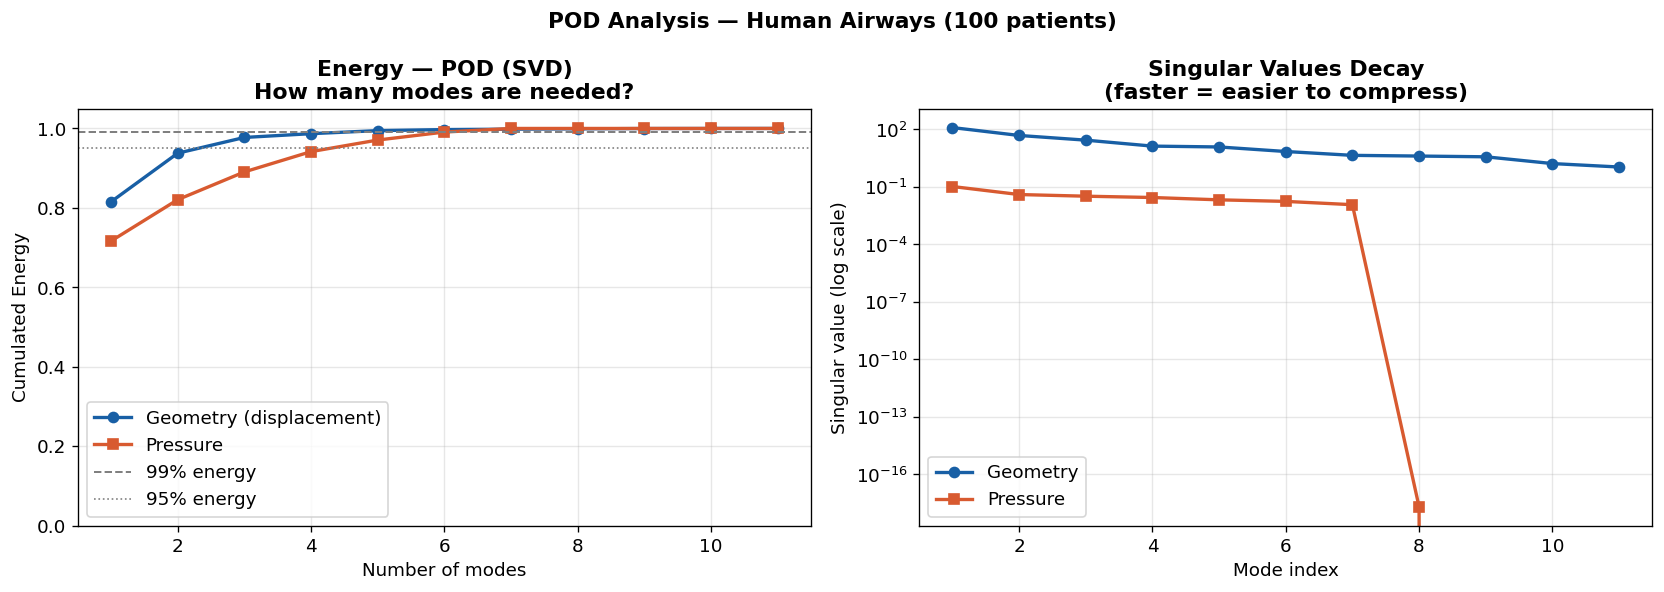


Geometry : 5 modes for 99% energy
Pressure : 6 modes for 99% energy

Interpretation:
  Pressure is LOW-RANK  -> dominated by 1 main airflow gradient mode
  Geometry is HIGHER-RANK -> patient-specific deformation needs more modes


In [ ]:
from numpy.linalg import svd

# Build snapshot matrices (regions x snapshots)
GEOM_COLS = ['glotis_max','larynx_max','upper_trachea_bottom_max',
             'gl_max','gr_max','glr_max','grr_max',
             'epiglotis_max','mouth_region_max',
             'upper_trachea_top_max','upper_trachea_middle_max']
PRES_COLS = ['glotis_mean_Pa','larynx_mean_Pa','upper_trachea_bottom_mean_Pa',
             'gl_mean_Pa','gr_mean_Pa','glr_mean_Pa','grr_mean_Pa',
             'epiglotis_mean_Pa','mouth_region_mean_Pa',
             'upper_trachea_top_mean_Pa','upper_trachea_middle_mean_Pa']

X_geom  = results[GEOM_COLS].values.T   # (n_regions x n_snapshots)
X_press = pressure[PRES_COLS].values.T

def perform_pod(X, name=''):
    """POD via SVD. Returns singular values and cumulated energy."""
    mean = np.mean(X, axis=1, keepdims=True)
    Xc   = X - mean                          # centre
    U, S, Vt = svd(Xc, full_matrices=False)  # economy SVD
    energy = np.cumsum(S**2) / np.sum(S**2)  # cumulated energy
    k95 = np.searchsorted(energy, 0.95) + 1
    k99 = np.searchsorted(energy, 0.99) + 1
    print(f'  {name}: {k95} modes for 95% energy,  {k99} modes for 99% energy')
    return U, S, energy

print('POD via SVD — snapshot matrices:')
print(f'  Geometry matrix : {X_geom.shape}  (regions x snapshots)')
print(f'  Pressure matrix : {X_press.shape}  (regions x snapshots)')
print()
U_geom,  S_geom,  E_geom  = perform_pod(X_geom,  'Geometry (displacement)')
U_press, S_press, E_press = perform_pod(X_press, 'Pressure')

# Energy convergence plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(S_geom)+1),  E_geom,  'o-', color='#185FA5',
             linewidth=2, markersize=6, label='Geometry (displacement)')
axes[0].plot(range(1, len(S_press)+1), E_press, 's-', color='#D85A30',
             linewidth=2, markersize=6, label='Pressure')
axes[0].axhline(0.99, color='gray', linestyle='--', linewidth=1.2, label='99% energy')
axes[0].axhline(0.95, color='gray', linestyle=':',  linewidth=1.0, label='95% energy')
axes[0].set_xlabel('Number of modes')
axes[0].set_ylabel('Cumulated Energy')
axes[0].set_title('Energy — POD (SVD)\nHow many modes are needed?', fontweight='bold')
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].semilogy(range(1, len(S_geom)+1),  S_geom,  'o-', color='#185FA5',
                 markersize=6, linewidth=2, label='Geometry')
axes[1].semilogy(range(1, len(S_press)+1), S_press, 's-', color='#D85A30',
                 markersize=6, linewidth=2, label='Pressure')
axes[1].set_xlabel('Mode index')
axes[1].set_ylabel('Singular value (log scale)')
axes[1].set_title('Singular Values Decay\n(faster = easier to compress)', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('POD Analysis — Human Airways (100 patients)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print()
print(f'Geometry : {np.searchsorted(E_geom,  0.99)+1} modes for 99% energy')
print(f'Pressure : {np.searchsorted(E_press, 0.99)+1} modes for 99% energy')
print()
print('Interpretation:')
print('  Pressure is LOW-RANK  -> dominated by 1 main airflow gradient mode')
print('  Geometry is HIGHER-RANK -> patient-specific deformation needs more modes')
